# Семантический поиск по технической документации

Нужно находить нужный раздел, даже если пользователь описывает задачу другими словами. Сравним TF-IDF и три модели Sentence Transformers на документации стандартной библиотеки Python 3.13.

Единица поиска — описание функции, класса или метода. Для каждой модели проверим фиксированные окна и разбиение с сохранением абзацев. В конце сравним качество, время и примеры ошибок.

In [1]:
import copy
import gc
import hashlib
import json
import os
import platform
import re
import time
from importlib.metadata import version
from pathlib import Path
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from bs4 import BeautifulSoup
from huggingface_hub import HfApi
from IPython.display import Markdown, display
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer

## 1. Настройки

In [2]:
ROOT = Path.cwd()
DATA = ROOT / "search_data"
RAW = DATA / "raw_html"
CACHE = ROOT / "search_cache"
RESULTS = ROOT / "search_results"
for folder in (DATA, RAW, CACHE, RESULTS):
    folder.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://docs.python.org/3.13/library/"
MODULES = ["pathlib", "re", "collections", "itertools", "functools", "json",
           "csv", "shutil", "tempfile", "subprocess", "concurrent.futures", "contextlib"]
CORPUS_PATH = DATA / "corpus.json"
QUERIES_PATH = DATA / "queries.json"
QRELS_PATH = DATA / "qrels.csv"
REFRESH_CORPUS = False
RECOMPUTE_EMBEDDINGS = False

In [3]:
SEED = 42
DEVICE = "cpu"
THREADS = 4
BATCH_SIZE = 32
MAX_TOKENS = 224
WINDOW_OVERLAP = 32
TOP_K = 5
BOOTSTRAP_SAMPLES = 2000
LATENCY_REPEATS = 2

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(THREADS)
pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [4]:
MODEL_SPECS = {
    "MiniLM": {"repo": "sentence-transformers/all-MiniLM-L6-v2", "prefix": ""},
    "MultiQA": {"repo": "sentence-transformers/multi-qa-MiniLM-L6-cos-v1", "prefix": ""},
    "BGE": {"repo": "BAAI/bge-small-en-v1.5",
            "prefix": "Represent this sentence for searching relevant passages: "},
}
STRATEGIES = ["fixed", "paragraphs"]
TFIDF_OPTIONS = {"ngram_range": (1, 2), "sublinear_tf": True,
                 "min_df": 1, "max_df": 1.0, "lowercase": True,
                 "token_pattern": r"(?u)\b[\w.]+\b"}

Настройки заданы до оценки качества. Все модели работают на одном CPU, с одинаковыми документами, запросами и чанками. Слова и имена API не удаляем: для документации они полезны.

Документы и запросы на английском, поэтому это исследование **одноязычного поиска**. Русские и смешанные запросы требуют отдельной проверки. Модели не дообучаем.

## 2. Корпус документации

Соберём описания API из 12 страниц [официальной документации Python 3.13](https://docs.python.org/3.13/library/index.html). Сохраним исходный HTML, URL с якорем, дату получения и контрольную сумму.

Вложенные методы выделяем в самостоятельные документы и удаляем из текста родительского класса. Навигация сайта и повторяющееся меню не входят в корпус. Лицензия документации — [PSF License](https://docs.python.org/3.13/license.html).

In [5]:
def read_page(module):
    path = RAW / f"{module}.html"
    if REFRESH_CORPUS or not path.exists():
        response = requests.get(urljoin(BASE_URL, module + ".html"), timeout=45)
        response.raise_for_status()
        path.write_text(response.content.decode("utf-8"), encoding="utf-8")
        time.sleep(0.2)
    return path.read_text(encoding="utf-8")

In [6]:
def extract_blocks(description):
    body = copy.deepcopy(description)
    for nested in body.select("dl.py, a.headerlink"):
        nested.decompose()
    blocks = []
    for node in body.select("p, pre, table"):
        if node.find_parent(["p", "pre", "table"]) is not None:
            continue
        text = re.sub(r"\s+", " ", node.get_text(" ", strip=True)).strip()
        if text:
            blocks.append(text)
    return blocks

In [7]:
def parse_page(module, html):
    soup = BeautifulSoup(html, "html.parser")
    records = []
    for node in soup.select("dl.py.function, dl.py.class, dl.py.method"):
        signature = node.find("dt", recursive=False)
        description = node.find("dd", recursive=False)
        if signature is None or description is None or not signature.get("id"):
            continue
        blocks = extract_blocks(description)
        if len(" ".join(blocks).split()) < 15:
            continue
        anchor = signature["id"]
        records.append({"doc_id": anchor, "module": module, "title": anchor,
                        "url": urljoin(BASE_URL, module + ".html#" + anchor),
                        "blocks": blocks, "text": "\n\n".join(blocks)})
    return records

In [8]:
def collect_corpus():
    documents, sources = [], []
    for module in MODULES:
        html = read_page(module)
        documents.extend(parse_page(module, html))
        sources.append({"module": module, "url": urljoin(BASE_URL, module + ".html"),
                        "sha256": hashlib.sha256(html.encode()).hexdigest()})
    documents = list({doc["doc_id"]: doc for doc in documents}.values())
    payload = {"retrieved_utc": pd.Timestamp.now(tz="UTC").isoformat(),
               "sources": sources, "documents": documents}
    CORPUS_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2))
    return payload

In [9]:
if CORPUS_PATH.exists() and not REFRESH_CORPUS:
    corpus_payload = json.loads(CORPUS_PATH.read_text())
else:
    corpus_payload = collect_corpus()
corpus = pd.DataFrame(corpus_payload["documents"]).sort_values("doc_id").reset_index(drop=True)
corpus["words"] = corpus["text"].str.split().str.len()
assert len(corpus) >= 100 and corpus["doc_id"].is_unique
assert corpus["text"].str.strip().ne("").all()
corpus[["doc_id", "module", "words"]].head(8)

,doc_id,module,words
0,collections.ChainMap,collections,250
1,collections.ChainMap.new_child,collections,108
2,collections.Counter,collections,302
3,collections.Counter.elements,collections,67
4,collections.Counter.most_common,collections,60
5,collections.Counter.subtract,collections,93
6,collections.Counter.total,collections,33
7,collections.Counter.update,collections,40


In [10]:
corpus_summary = pd.Series({
    "Документов": len(corpus), "Модулей": corpus["module"].nunique(),
    "Всего слов": corpus["words"].sum(), "Точных дублей текста": corpus["text"].duplicated().sum(),
    "Медиана длины": corpus["words"].median(), "90-й процентиль": corpus["words"].quantile(0.9),
    "Максимум слов": corpus["words"].max(),
})
display(corpus_summary.to_frame("Значение").round(1))

,Значение
Документов,258.0
Модулей,12.0
Всего слов,38203.0
Точных дублей текста,0.0
Медиана длины,92.0
90-й процентиль,315.3
Максимум слов,2320.0


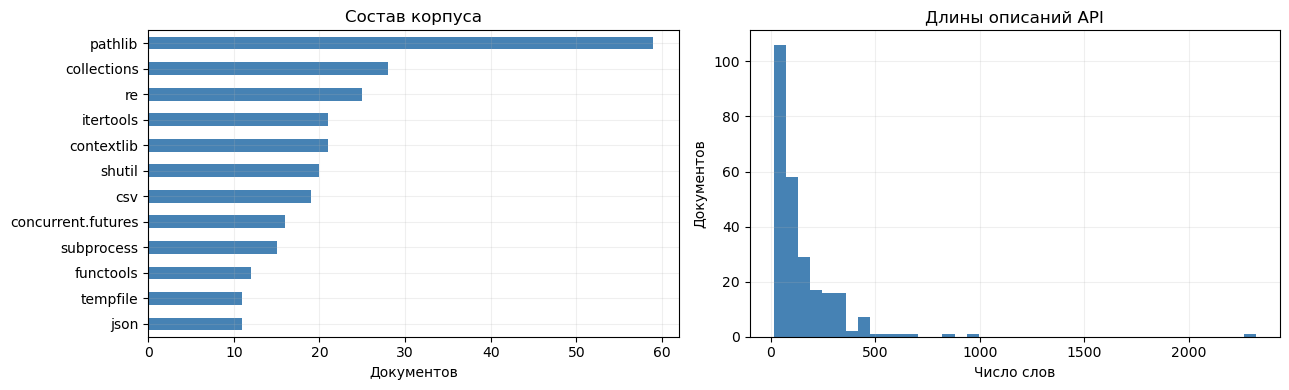

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
corpus.groupby("module").size().sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set(xlabel="Документов", ylabel="", title="Состав корпуса")
axes[1].hist(corpus["words"], bins=40, color="steelblue")
axes[1].set(xlabel="Число слов", ylabel="Документов", title="Длины описаний API")
fig.tight_layout()
plt.show()

В корпусе **258 документов и 38 203 слова**, точных дублей текста нет. Больше всего документов у `pathlib` — 59. Медианная длина составляет 92 слова, но максимальная достигает 2320 слов (`subprocess.Popen`). Поэтому передавать весь документ в модель нельзя: длинные описания нужно разбивать, сохраняя их связь с исходным API.

Лимит 224 токена выбран с запасом относительно минимального окна моделей (256 у MiniLM). Это ограничение длины чанка, а не обрезание всего документа до 224 токенов.

## 3. Поисковые запросы и разметка

Запросы описывают точные API, обычные задачи и задачи с дополнительными ограничениями. Разделение на development и test зафиксировано заранее. Development используется для выбора варианта, test — для итоговой оценки всех вариантов.

Релевантным считаем документ, который непосредственно описывает нужную операцию. Совпадения темы и ссылки на соседний API недостаточно. В `qrels.csv` для каждой положительной связи сохранены обоснование и фрагмент документа. Неразмеченные пары считаются нерелевантными в рамках этой ограниченной коллекции.

Первоначальные запросы и проверка содержания подготовлены с помощью Codex. Это **не независимая ручная проверка человеком**. Для выполнения этого требования задания автору работы нужно просмотреть `annotation_review.html`; поле `human_verified` изначально равно `False`. Такой статус явно сохранён и не подменяется автоматической проверкой.

In [ ]:
queries = pd.read_json(QUERIES_PATH)
qrels = pd.read_csv(QRELS_PATH, keep_default_na=False)
queries[["query_id", "split", "difficulty", "query"]]

,query_id,split,difficulty,query
0,D01,dev,перефразирование,Read a whole text file into one string and make sure the file is closed afterwards.
1,D02,dev,точный API,re.findall: return all non-overlapping matches as strings.
2,D03,dev,точный API,json.dumps: serialize a Python dictionary to a JSON string.
3,D04,dev,с ограничениями,Copy a file to a new location while preserving its metadata as far as the platform permits.
4,D05,dev,точный API,itertools.product repeat: Cartesian product of an iterable with itself.
5,D06,dev,перефразирование,"Which items occur most often, and how many times does each of them occur?"
6,D07,dev,с ограничениями,Run tasks in worker processes and replace each worker after a fixed number of completed tasks.
7,D08,dev,с ограничениями,An object has close() but no context manager methods. Ensure it is closed even when the body fails.
8,D09,dev,перефразирование,Create a callable with some arguments already filled in so callers only supply the remaining ones.
9,D10,dev,перефразирование,Infer the delimiter of a CSV file from a sample when its dialect is unknown.


In [13]:
relevant = qrels.groupby("query_id")["doc_id"].agg(set).to_dict()
query_counts = pd.crosstab(queries["split"], queries["difficulty"])
display(query_counts)
display(qrels[["query_id", "doc_id", "reason", "human_verified"]].head(8))

difficulty,перефразирование,с ограничениями,точный API
split,,,
dev,4,3,3
test,8,9,7


,query_id,doc_id,reason,human_verified
0,D01,pathlib.Path.read_text,Метод возвращает декодированный текст и закрывает открытый файл.,False
1,D02,re.findall,Описаны список совпадений и вариант для скомпилированного шаблона.,False
2,D02,re.Pattern.findall,Описаны список совпадений и вариант для скомпилированного шаблона.,False
3,D03,json.dumps,Запрошена конкретная функция сериализации в строку.,False
4,D04,shutil.copy2,copy2 копирует данные и пытается сохранить метаданные; copystat не копирует содержимое.,False
5,D05,itertools.product,Документ описывает декартово произведение и аргумент repeat.,False
6,D06,collections.Counter.most_common,Метод возвращает элементы вместе с частотами в порядке убывания; общий Counter не описывает сортировку.,False
7,D07,concurrent.futures.ProcessPoolExecutor,Параметр max_tasks_per_child ограничивает число задач на процесс.,False


Получилось **34 запроса**: 10 development и 24 test. На тесте 7 запросов с точным API, 8 перефразированных и 9 с дополнительными ограничениями. Для 34 запросов размечены 42 положительные связи с документами: у части задач есть несколько допустимых API.

Формулировки, разделение и положительные связи сохранены до вычисления поисковых результатов. Несколько релевантных документов встречаются, например, у обычной и скомпилированной версии регулярного выражения; поэтому одной метрики попадания первого ответа недостаточно.

## 4. Разбиение документов

**Фиксированные окна:** до 224 WordPiece-токенов вместе с названием API, перекрытие 32 токена. Окно может разрезать абзац.

**Абзацы:** последовательно объединяем целые HTML-абзацы и блоки примеров в тот же лимит; слишком длинный блок делим на окна. Между готовыми группами абзацев перекрытия нет.

Это сравнение двух практических стратегий; они различаются и границами, и перекрытием. Оно не позволяет приписать весь эффект только границам абзацев. Общий токенизатор проверяется на совместимость со всеми тремя моделями.

In [14]:
lock_path = DATA / "model_revisions.json"
if lock_path.exists():
    revisions = json.loads(lock_path.read_text())
else:
    revisions = {name: HfApi().model_info(spec["repo"]).sha
                 for name, spec in MODEL_SPECS.items()}
    lock_path.write_text(json.dumps(revisions, indent=2))

tokenizer = AutoTokenizer.from_pretrained(MODEL_SPECS["MiniLM"]["repo"],
                                          revision=revisions["MiniLM"], cache_dir=str(CACHE / "hf"))

In [15]:
def token_windows(text, budget):
    encoded = tokenizer(text, add_special_tokens=False, return_offsets_mapping=True,
                        truncation=False, verbose=False)
    offsets = encoded["offset_mapping"]
    pieces, start = [], 0
    while start < len(offsets):
        end = min(start + budget, len(offsets))
        part = text[offsets[start][0]:offsets[end - 1][1]]
        while len(tokenizer.encode(part, add_special_tokens=False, verbose=False)) > budget:
            end -= 1
            part = text[offsets[start][0]:offsets[end - 1][1]]
        pieces.append(part)
        if end == len(offsets):
            break
        start = max(start + 1, end - WINDOW_OVERLAP)
    return pieces

In [16]:
def paragraph_chunks(blocks, budget):
    result, current, used = [], [], 0
    for block in blocks:
        size = len(tokenizer.encode(block, add_special_tokens=False, verbose=False))
        if size > budget:
            if current:
                result.append("\n\n".join(current))
                current, used = [], 0
            result.extend(token_windows(block, budget))
        else:
            if current and used + size > budget:
                result.append("\n\n".join(current))
                current, used = [], 0
            current.append(block)
            used += size
    if current:
        result.append("\n\n".join(current))
    return result

In [17]:
def make_chunks(strategy):
    rows = []
    for doc in corpus.itertuples():
        prefix = doc.title + "\n"
        budget = MAX_TOKENS - len(tokenizer.encode(prefix, add_special_tokens=False)) - 2
        parts = (token_windows(doc.text, budget) if strategy == "fixed"
                 else paragraph_chunks(doc.blocks, budget))
        for i, part in enumerate(parts):
            rows.append({"chunk_id": f"{doc.doc_id}:{i}", "doc_id": doc.doc_id,
                         "text": prefix + part})
    return pd.DataFrame(rows)

In [18]:
chunks = {strategy: make_chunks(strategy) for strategy in STRATEGIES}
chunk_summary = []
for strategy, frame in chunks.items():
    lengths = [len(tokenizer.encode(text, verbose=False)) for text in frame["text"]]
    assert max(lengths) <= MAX_TOKENS
    assert set(frame["doc_id"]) == set(corpus["doc_id"])
    frame.to_json(DATA / f"chunks_{strategy}.json", orient="records", force_ascii=False)
    chunk_summary.append({"strategy": strategy, "chunks": len(frame),
                          "median_tokens": np.median(lengths), "max_tokens": max(lengths)})
chunk_summary = pd.DataFrame(chunk_summary)
chunk_summary

,strategy,chunks,median_tokens,max_tokens
0,fixed,430,176.0,224
1,paragraphs,446,151.5,224


Фиксированные окна дали **430 чанков**, разбиение по абзацам — **446**, то есть на 3,7% больше. Медиана длины уменьшилась со 176 до 151,5 токена: сохранение границ абзацев оставляет часть окна незаполненной. Обе стратегии покрывают все 258 документов, максимальная длина равна 224 токенам. Ни один чанк не требует скрытого обрезания моделью.

## 5. Оценка качества

Основная метрика — **MRR@5**: среднее обратное место первого релевантного документа в первых пяти результатах; если его нет, значение 0. Она подходит, когда пользователю нужен быстрый ответ.

**Recall@5** показывает, какая доля всех размеченных релевантных документов попала в выдачу. **nDCG@5** учитывает позиции всех релевантных документов с логарифмическим снижением веса. Используем бинарную релевантность. **Hit@1** — доля запросов с релевантным первым результатом.

Ранжируем уникальные исходные документы по максимальному сходству их чанков. Все варианты используют одинаковое правило. Оно может давать длинным документам с большим количеством чанков больше шансов; это ограничение учитываем при интерпретации.

In [19]:
doc_ids = corpus["doc_id"].to_numpy()
doc_positions = {doc_id: i for i, doc_id in enumerate(doc_ids)}
query_texts = queries["query"].tolist()
query_ids = queries["query_id"].tolist()
query_position = {qid: i for i, qid in enumerate(query_ids)}

def document_scores(chunk_scores, chunk_frame):
    parent = chunk_frame["doc_id"].map(doc_positions).to_numpy()
    scores = np.full((len(chunk_scores), len(doc_ids)), -np.inf, dtype=np.float32)
    for i, row in enumerate(chunk_scores):
        np.maximum.at(scores[i], parent, row)
    return scores

In [20]:
def evaluate_scores(scores, name, strategy):
    rows = []
    order = np.argsort(-scores, axis=1, kind="stable")
    for i, query in enumerate(queries.itertuples()):
        expected = relevant[query.query_id]
        ranked = doc_ids[order[i, :TOP_K]].tolist()
        hits = np.array([doc in expected for doc in ranked], dtype=float)
        ranks = np.flatnonzero(hits) + 1
        discounts = 1 / np.log2(np.arange(2, TOP_K + 2))
        rows.append({"model": name, "strategy": strategy, "query_id": query.query_id,
                     "split": query.split, "difficulty": query.difficulty,
                     "MRR@5": 1 / ranks[0] if len(ranks) else 0.0,
                     "Recall@5": hits.sum() / len(expected), "Hit@1": hits[0],
                     "nDCG@5": (hits * discounts).sum() / discounts[:min(TOP_K, len(expected))].sum(),
                     "top5": ranked})
    return pd.DataFrame(rows)

In [21]:
toy_scores = np.zeros((len(queries), len(doc_ids)), dtype=np.float32)
for i, qid in enumerate(query_ids):
    for doc_id in relevant[qid]:
        toy_scores[i, doc_positions[doc_id]] = 1
perfect = evaluate_scores(toy_scores, "check", "check")
assert np.allclose(perfect["MRR@5"], 1)
assert np.allclose(perfect["nDCG@5"], 1)
assert np.allclose(perfect["Recall@5"], 1)
print("Проверка метрик: идеальная выдача даёт единицу.")

Проверка метрик: идеальная выдача даёт единицу.


## 6. Базовый поиск TF-IDF

In [22]:
def run_tfidf(strategy):
    frame = chunks[strategy]
    vectorizer = TfidfVectorizer(**TFIDF_OPTIONS)
    start = time.perf_counter()
    matrix = vectorizer.fit_transform(frame["text"])
    build_seconds = time.perf_counter() - start
    start = time.perf_counter()
    query_matrix = vectorizer.transform(query_texts)
    raw = (query_matrix @ matrix.T).toarray()
    scores = document_scores(raw, frame)
    query_ms = (time.perf_counter() - start) * 1000 / len(queries)
    size = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
    info = {"model": "TF-IDF", "strategy": strategy, "build_s": build_seconds,
            "batch_query_ms": query_ms, "index_MiB": size / 2**20, "features": matrix.shape[1]}
    return scores, info, vectorizer, matrix

In [23]:
scores_by_variant, evaluation_frames, timings, tfidf_indexes = {}, [], [], {}
for strategy in STRATEGIES:
    scores, info, vectorizer, matrix = run_tfidf(strategy)
    scores_by_variant[("TF-IDF", strategy)] = scores
    evaluation_frames.append(evaluate_scores(scores, "TF-IDF", strategy))
    timings.append(info)
    tfidf_indexes[strategy] = (vectorizer, matrix)
pd.concat(evaluation_frames).groupby(["model", "strategy", "split"])[
    ["MRR@5", "Recall@5", "nDCG@5", "Hit@1"]].mean().round(3)

MRR@5  Recall@5  nDCG@5  Hit@1
model  strategy   split                                
TF-IDF fixed      dev    0.603     0.750   0.617  0.500
                  test   0.543     0.646   0.539  0.458
       paragraphs dev    0.603     0.750   0.620  0.500
                  test   0.538     0.646   0.540  0.458

На тестовых запросах TF-IDF получил MRR@5 **0,543** для фиксированных окон и **0,538** для абзацев. В обоих случаях первый результат релевантен для 11 из 24 запросов, а Recall@5 составляет 0,646. Само изменение границ чанков почти не улучшило лексический поиск; нужен способ сопоставлять перефразированные задачи с описаниями API.

## 7. Семантический поиск

Сравним [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), [multi-qa-MiniLM-L6-cos-v1](https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1) и [bge-small-en-v1.5](https://huggingface.co/BAAI/bge-small-en-v1.5).

MiniLM — компактная универсальная модель. MultiQA ориентирована на поиск ответов на вопросы. BGE — ещё одна модель для поиска; к запросу добавляем инструкцию из её model card, к документам — нет. Все три выдают векторы размерности 384.

Нормализуем векторы: скалярное произведение становится косинусным сходством. Используем точный поиск, без приближённого индекса. Версии моделей зафиксированы commit hash. При повторном запуске используем сохранённые эмбеддинги с проверкой отпечатка входных данных.

In [24]:
def load_model(name):
    model = SentenceTransformer(MODEL_SPECS[name]["repo"], device=DEVICE,
                                revision=revisions[name], cache_folder=str(CACHE / "hf"))
    assert model.tokenizer.get_vocab() == tokenizer.get_vocab()
    sample = chunks["fixed"]["text"].tolist() + chunks["paragraphs"]["text"].tolist()
    lengths = [len(ids) for ids in model.tokenizer(sample, truncation=False)["input_ids"]]
    assert max(lengths) <= model.max_seq_length
    model.encode(["Warm up the text encoder."], normalize_embeddings=True)
    return model

In [25]:
def cache_key(name, texts):
    payload = {"model": MODEL_SPECS[name], "revision": revisions[name], "texts": texts,
               "normalization": True, "sentence_transformers": version("sentence-transformers")}
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()

In [26]:
def encode_cached(model, name, texts, label):
    stem = CACHE / f"{name}_{label}_{cache_key(name, texts)[:16]}"
    if stem.with_suffix(".npz").exists() and not RECOMPUTE_EMBEDDINGS:
        saved = np.load(stem.with_suffix(".npz"))
        return saved["embeddings"], float(saved["seconds"]), True
    start = time.perf_counter()
    vectors = model.encode(texts, batch_size=BATCH_SIZE, normalize_embeddings=True,
                           show_progress_bar=False, convert_to_numpy=True)
    seconds = time.perf_counter() - start
    np.savez_compressed(stem.with_suffix(".npz"), embeddings=vectors, seconds=seconds)
    return vectors, seconds, False

In [27]:
def semantic_variant(model, name, strategy, query_vectors):
    frame = chunks[strategy]
    vectors, seconds, cached = encode_cached(model, name, frame["text"].tolist(), strategy)
    start = time.perf_counter()
    scores = document_scores(query_vectors @ vectors.T, frame)
    search_ms = (time.perf_counter() - start) * 1000 / len(queries)
    info = {"model": name, "strategy": strategy, "build_s": seconds,
            "search_ms": search_ms, "index_MiB": vectors.nbytes / 2**20,
            "features": vectors.shape[1], "cached": cached}
    return scores, info, vectors

In [28]:
def single_query_latency(encode_one, index, frame):
    samples = []
    encode_one(query_texts[0])
    for _ in range(LATENCY_REPEATS):
        for text in query_texts:
            start = time.perf_counter()
            raw = encode_one(text) @ index.T
            raw = raw.toarray() if hasattr(raw, "toarray") else raw
            scores = document_scores(raw, frame)
            np.argsort(-scores[0], kind="stable")[:TOP_K]
            samples.append((time.perf_counter() - start) * 1000)
    return {"latency_p50_ms": np.median(samples), "latency_p95_ms": np.quantile(samples, 0.95)}

In [29]:
model_details, dense_indexes = [], {}
for name, spec in MODEL_SPECS.items():
    print(f"Модель: {name}", flush=True)
    model = load_model(name)
    texts = [spec["prefix"] + text for text in query_texts]
    query_vectors, encode_s, _ = encode_cached(model, name, texts, "queries")
    model_details.append({"model": name, "parameters": sum(p.numel() for p in model.parameters()),
                          "dimension": model.get_sentence_embedding_dimension(),
                          "max_seq_length": model.max_seq_length, "revision": revisions[name]})
    for strategy in STRATEGIES:
        scores, info, vectors = semantic_variant(model, name, strategy, query_vectors)
        scores_by_variant[(name, strategy)] = scores
        evaluation_frames.append(evaluate_scores(scores, name, strategy))
        encoder = lambda text: model.encode([spec["prefix"] + text], normalize_embeddings=True)
        info.update(single_query_latency(encoder, vectors, chunks[strategy]))
        info["batch_query_ms"] = encode_s * 1000 / len(queries) + info["search_ms"]
        timings.append(info)
        dense_indexes[(name, strategy)] = vectors
    del model
    gc.collect()
display(pd.DataFrame(model_details))

Модель: MiniLM


Модель: MultiQA


Модель: BGE


,model,parameters,dimension,max_seq_length,revision
0,MiniLM,22713216,384,256,1110a243fdf4706b3f48f1d95db1a4f5529b4d41
1,MultiQA,22713216,384,512,b207367332321f8e44f96e224ef15bc607f4dbf0
2,BGE,33360000,384,512,5c38ec7c405ec4b44b94cc5a9bb96e735b38267a


Все модели строят векторы из 384 чисел, поэтому при одинаковом числе чанков размер плотного индекса одинаков. У MiniLM и MultiQA по **22,71 млн параметров**, у BGE — **33,36 млн**. Максимальное окно отличается, но фактическая длина входа в этом эксперименте одинакова. Более крупная модель не получает преимущество за счёт дополнительного текста.

In [30]:
for info in timings:
    if info["model"] == "TF-IDF":
        vectorizer, matrix = tfidf_indexes[info["strategy"]]
        info.update(single_query_latency(lambda text: vectorizer.transform([text]), matrix, chunks[info["strategy"]]))
timing_table = pd.DataFrame(timings)
timing_table[["model", "strategy", "build_s", "latency_p50_ms", "latency_p95_ms", "index_MiB"]].round(3)

,model,strategy,build_s,latency_p50_ms,latency_p95_ms,index_MiB
0,TF-IDF,fixed,0.105,1.680,2.179,0.668
1,TF-IDF,paragraphs,0.090,1.582,1.626,0.621
2,MiniLM,fixed,22.246,118.060,127.606,0.630
3,MiniLM,paragraphs,23.410,118.076,124.851,0.653
4,MultiQA,fixed,22.392,118.358,128.401,0.630
5,MultiQA,paragraphs,25.571,118.293,127.852,0.653
6,BGE,fixed,44.962,152.989,171.627,0.630
7,BGE,paragraphs,47.526,152.134,194.401,0.653


TF-IDF построил индекс за **0.09 с**, а кодирование документов нейросетями заняло **22–48 с** в исходном запуске. Медианная задержка одного запроса составила примерно **1.6 мс** для TF-IDF, **118 мс** для MiniLM и **153 мс** для BGE.

Плотный индекс занимает около 0,63–0,65 MiB. Вес модели в эту величину не входит. Семантический поиск заметно дороже лексического, поэтому выигрыш качества нужно сопоставлять с допустимой задержкой; документы разумно кодировать заранее.

Время построения индекса исключает скачивание и загрузку модели. Для эмбеддингов при чтении кэша показано исходное измеренное время кодирования. p50/p95 измерены заново: один запрос, его кодирование, точный поиск, объединение чанков и сортировка; модель уже прогрета.

Размер индекса — массив векторов либо CSR-матрица TF-IDF. Это не полная память процесса: веса модели, словарь и служебные объекты сюда не входят. Измерения зависят от нагрузки на компьютер.

## 8. Сравнение вариантов

Выбираем семантический вариант и TF-IDF отдельно по MRR@5 на development. При равенстве используем nDCG@5, затем заранее фиксированный алфавитный порядок имён вариантов; среди двух равных стратегий это `fixed`. Тестовые запросы на выбор не влияют.

In [31]:
per_query = pd.concat(evaluation_frames, ignore_index=True)
metric_names = ["MRR@5", "Recall@5", "nDCG@5", "Hit@1"]
summary = per_query.groupby(["split", "model", "strategy"])[metric_names].mean().reset_index()
dev_results = summary.query("split == 'dev'").sort_values(
    ["MRR@5", "nDCG@5", "model", "strategy"], ascending=[False, False, True, True])
display(dev_results.round(3))

,split,model,strategy,MRR@5,Recall@5,nDCG@5,Hit@1
0,dev,BGE,fixed,0.900,0.95,0.888,0.8
1,dev,BGE,paragraphs,0.900,0.95,0.888,0.8
2,dev,MiniLM,fixed,0.728,0.95,0.748,0.6
3,dev,MiniLM,paragraphs,0.673,0.95,0.707,0.5
4,dev,MultiQA,fixed,0.620,0.75,0.618,0.5
7,dev,TF-IDF,paragraphs,0.603,0.75,0.620,0.5
6,dev,TF-IDF,fixed,0.603,0.75,0.617,0.5
5,dev,MultiQA,paragraphs,0.595,0.75,0.598,0.5


На development лучший результат показала **BGE**: MRR@5 = 0,900 у обеих стратегий. При равенстве метрик по заданному правилу выбраны фиксированные окна. Лучший базовый вариант — TF-IDF с абзацами: MRR@5 у двух стратегий одинаков, но nDCG@5 немного выше у абзацев.

In [32]:
best_row = dev_results.query("model != 'TF-IDF'").iloc[0]
best_key = (best_row["model"], best_row["strategy"])
baseline_row = dev_results.query("model == 'TF-IDF'").iloc[0]
baseline_key = (baseline_row["model"], baseline_row["strategy"])
print("Выбранный семантический вариант по dev:", best_key)
print("Выбранный базовый вариант по dev:", baseline_key)
test_results = summary.query("split == 'test'").sort_values("MRR@5", ascending=False)
display(test_results.round(3))

observed_best_row = test_results.query("model != 'TF-IDF'").iloc[0]
observed_best_key = (observed_best_row["model"], observed_best_row["strategy"])
print("Лидер test (исследовательское наблюдение):", observed_best_key)

Выбранный семантический вариант по dev: ('BGE', 'fixed')
Выбранный базовый вариант по dev: ('TF-IDF', 'paragraphs')


,split,model,strategy,MRR@5,Recall@5,nDCG@5,Hit@1
11,test,MiniLM,paragraphs,0.747,0.812,0.742,0.667
9,test,BGE,paragraphs,0.696,0.771,0.706,0.625
13,test,MultiQA,paragraphs,0.647,0.812,0.675,0.542
8,test,BGE,fixed,0.639,0.771,0.667,0.542
12,test,MultiQA,fixed,0.639,0.792,0.652,0.542
10,test,MiniLM,fixed,0.616,0.688,0.616,0.542
14,test,TF-IDF,fixed,0.543,0.646,0.539,0.458
15,test,TF-IDF,paragraphs,0.538,0.646,0.540,0.458


Лидер test (исследовательское наблюдение): ('MiniLM', 'paragraphs')


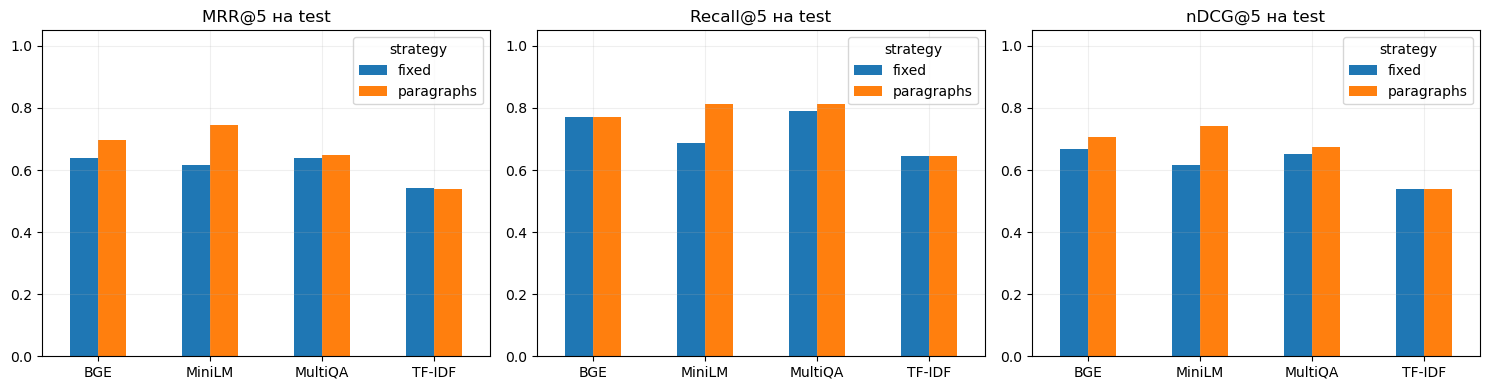

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MRR@5", "Recall@5", "nDCG@5"]):
    test_results.pivot(index="model", columns="strategy", values=metric).plot.bar(ax=ax)
    ax.set(title=metric + " на test", xlabel="", ylim=(0, 1.05))
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

На test лидер изменился: **MiniLM + paragraphs** получил MRR@5 = **0,747**, Recall@5 = **0,813**, nDCG@5 = **0,742**, Hit@1 = **0,667** (16 из 24). У выбранного базового TF-IDF MRR@5 = 0,538: наблюдаемая разница составляет **0,208**.

Заранее выбранный **BGE + fixed** получил MRR@5 = **0,639**, Recall@5 = 0,771 и Hit@1 = 0,542. Его разница с базовым вариантом меньше — **0,101**. Таким образом, MiniLM с абзацами — лидер этой итоговой таблицы, но он выбран по уже просмотренному test. Для подтверждения такого выбора нужен новый независимый набор запросов.

In [34]:
by_difficulty = per_query.query("split == 'test'").groupby(
    ["model", "strategy", "difficulty"])[metric_names].mean()
display(by_difficulty.round(3))

MRR@5  Recall@5  nDCG@5  Hit@1
model   strategy   difficulty                                      
BGE     fixed      перефразирование  0.406     0.562   0.441  0.250
                   с ограничениями   0.565     0.778   0.609  0.444
                   точный API        1.000     1.000   1.000  1.000
        paragraphs перефразирование  0.500     0.562   0.502  0.375
                   с ограничениями   0.633     0.778   0.660  0.556
                   точный API        1.000     1.000   1.000  1.000
MiniLM  fixed      перефразирование  0.473     0.562   0.452  0.375
                   с ограничениями   0.500     0.556   0.506  0.444
                   точный API        0.929     1.000   0.947  0.857
        paragraphs перефразирование  0.635     0.688   0.596  0.500
                   с ограничениями   0.648     0.778   0.672  0.556
                   точный API        1.000     1.000   1.000  1.000
MultiQA fixed      перефразирование  0.583     0.688   0.567  0.500
                   с ограничениями   0.491     0.722   0.519  0.333
                   точный API        0.893     1.000   0.919  0.857
        paragraphs перефразирование  0.431     0.688   0.469  0.250
                   с ограничениями   0.648     0.778   0.668  0.556
                   точный API        0.893     1.000   0.919  0.857
TF-IDF  fixed      перефразирование  0.379     0.500   0.343  0.250
                   с ограничениями   0.407     0.500   0.409  0.333
                   точный API        0.905     1.000   0.929  0.857
        paragraphs перефразирование  0.438     0.500   0.386  0.375
                   с ограничениями   0.352     0.500   0.381  0.222
                   точный API        0.893     1.000   0.919  0.857

Запросы с точным API проще: BGE с обеими стратегиями и MiniLM с абзацами нашли правильный документ первым во всех 7 случаях. На перефразированных запросах MRR@5 у MiniLM с абзацами — **0,635**, у TF-IDF с абзацами — **0,438**. На задачах с ограничениями значения равны **0,648** и **0,352**.

При этом BGE с фиксированными окнами на группе перефразирований уступил TF-IDF: 0,406 против 0,438. Семантическая модель не гарантирует улучшения каждого типа запросов.

In [35]:
test_pairs = per_query.query("split == 'test'").pivot(
    index="query_id", columns=["model", "strategy"], values="MRR@5")
deltas = (test_pairs[best_key] - test_pairs[baseline_key]).to_numpy()
rng = np.random.default_rng(SEED)
bootstrap = rng.choice(deltas, size=(BOOTSTRAP_SAMPLES, len(deltas)), replace=True).mean(axis=1)
ci = np.quantile(bootstrap, [0.025, 0.975])
print(f"Разница MRR@5: {deltas.mean():.3f}; парный bootstrap 95%: [{ci[0]:.3f}, {ci[1]:.3f}]")

Разница MRR@5: 0.101; парный bootstrap 95%: [-0.049, 0.243]


Парный 95%-интервал для разницы заранее выбранного BGE + fixed и базового TF-IDF равен примерно **[−0,049; 0,243]** и включает ноль. На 24 запросах нельзя уверенно заявить о стабильном преимуществе этого выбора.

Bootstrap здесь показывает чувствительность среднего к составу имеющегося набора. Он не устраняет субъективность разметки и не превращает специально составленные запросы в случайную выборку реальных пользователей.

In [36]:
chunk_effect = test_results.pivot(index="model", columns="strategy", values=metric_names)
chunk_delta = pd.DataFrame({metric: chunk_effect[(metric, "paragraphs")] - chunk_effect[(metric, "fixed")]
                            for metric in metric_names})
chunk_delta.columns = ["Δ " + metric for metric in metric_names]
chunk_delta.round(3)

,Δ MRR@5,Δ Recall@5,Δ nDCG@5,Δ Hit@1
model,,,,
BGE,0.057,0.000,0.040,0.083
MiniLM,0.131,0.125,0.126,0.125
MultiQA,0.008,0.021,0.023,0.000
TF-IDF,-0.005,0.000,0.001,0.000


Переход к абзацам изменил тестовый MRR@5 на **+0,131 у MiniLM**, **+0,057 у BGE**, **+0,008 у MultiQA** и **−0,005 у TF-IDF**. Наибольший эффект получен у MiniLM. Recall@5 у MiniLM вырос с 0,688 до 0,813: изменились не только позиции уже найденных документов, но и их присутствие в первых пяти результатах.

Вероятное объяснение — целый абзац сохраняет связь между операцией, параметрами и примером. Это интерпретация, а не доказательство причины: стратегии также различаются перекрытием и количеством чанков.

## 9. Разбор запросов и ошибок

In [37]:
def first_relevant_rank(key, qid):
    row = scores_by_variant[key][query_position[qid]]
    order = doc_ids[np.argsort(-row, kind="stable")]
    return next(i + 1 for i, doc in enumerate(order) if doc in relevant[qid])

case_table = queries.query("split == 'test'").copy()
case_table["TF-IDF rank"] = [first_relevant_rank(baseline_key, qid) for qid in case_table["query_id"]]
case_table["Semantic rank"] = [first_relevant_rank(best_key, qid) for qid in case_table["query_id"]]
case_table["MRR gain"] = case_table["query_id"].map(test_pairs[best_key] - test_pairs[baseline_key])
case_table["Test leader rank"] = [first_relevant_rank(observed_best_key, qid) for qid in case_table["query_id"]]
case_table["Leader MRR gain"] = case_table["query_id"].map(test_pairs[observed_best_key] - test_pairs[baseline_key])
case_table[["query_id", "query", "TF-IDF rank", "Semantic rank", "Test leader rank"]]

,query_id,query,TF-IDF rank,Semantic rank,Test leader rank
10,Q01,functools.lru_cache: how do maxsize and typed affect caching?,1,1,1
11,Q02,The same calculation keeps running for arguments I have already seen. How do I reuse earlier answers?,1,18,2
12,Q03,Implement setup and cleanup around a with block using a generator instead of writing a class.,1,1,1
13,Q04,"I need a scratch workspace that disappears, including everything inside it, when the block finishes.",25,6,3
14,Q05,"I am consuming a stream and need packets of five items, without reading all of it into memory.",62,28,31
15,Q06,"Given daily measurements, visit yesterday and today together, then today and tomorrow.",204,52,86
16,Q07,"Several streams should behave like one long stream, one after the other, without creating a big intermedia...",179,4,4
17,Q08,"Skip the first ten items in a generator, then take the next twenty.",41,4,3
18,Q09,Use json.dump to write a dictionary to an already opened file.,1,1,1
19,Q10,Use json.load to read a Python object from an opened JSON file.,1,1,1


In [38]:
def show_results(key, qid, k=5):
    scores = scores_by_variant[key][query_position[qid]]
    positions = np.argsort(-scores, kind="stable")[:k]
    result = corpus.iloc[positions][["doc_id", "url"]].copy()
    result.insert(0, "rank", np.arange(1, k + 1))
    result["relevant"] = result["doc_id"].isin(relevant[qid])
    result["score"] = scores[positions]
    return result.reset_index(drop=True)

Ниже разбираем **MiniLM + paragraphs**, лидера итоговой тестовой таблицы. Это разбор наблюдаемого результата, а не новая независимая оценка выбранной на test модели. В столбце `Semantic rank` выше сохранён заранее выбранный BGE + fixed; `Test leader rank` относится к MiniLM + paragraphs.

In [39]:
positive_cases = case_table.sort_values("Leader MRR gain", ascending=False).head(2)
for query in positive_cases.itertuples():
    display(Markdown(f"**{query.query_id}: {query.query}**"))
    display(show_results(baseline_key, query.query_id))
    display(show_results(observed_best_key, query.query_id))

**Q21: Search for user-provided text literally even if it contains dots, brackets or stars with special regex meanings.**

,rank,doc_id,url,relevant,score
0,1,tempfile.mkdtemp,https://docs.python.org/3.13/library/tempfile.html#tempfile.mkdtemp,False,0.089589
1,2,shutil.which,https://docs.python.org/3.13/library/shutil.html#shutil.which,False,0.087570
2,3,re.RegexFlag,https://docs.python.org/3.13/library/re.html#re.RegexFlag,False,0.078241
3,4,subprocess.Popen,https://docs.python.org/3.13/library/subprocess.html#subprocess.Popen,False,0.068045
4,5,concurrent.futures.ProcessPoolExecutor,https://docs.python.org/3.13/library/concurrent.futures.html#concurrent.futures.ProcessPoolExecutor,False,0.059781


,rank,doc_id,url,relevant,score
0,1,re.escape,https://docs.python.org/3.13/library/re.html#re.escape,True,0.469050
1,2,re.Pattern.fullmatch,https://docs.python.org/3.13/library/re.html#re.Pattern.fullmatch,False,0.431196
2,3,re.Pattern.match,https://docs.python.org/3.13/library/re.html#re.Pattern.match,False,0.426965
3,4,re.Pattern.search,https://docs.python.org/3.13/library/re.html#re.Pattern.search,False,0.426837
4,5,re.match,https://docs.python.org/3.13/library/re.html#re.match,False,0.422614


**Q22: Ignore only selected exception types inside a with block and continue after the block.**

,rank,doc_id,url,relevant,score
0,1,contextlib.contextmanager,https://docs.python.org/3.13/library/contextlib.html#contextlib.contextmanager,False,0.162935
1,2,contextlib.closing,https://docs.python.org/3.13/library/contextlib.html#contextlib.closing,False,0.111646
2,3,pathlib.Path.is_block_device,https://docs.python.org/3.13/library/pathlib.html#pathlib.Path.is_block_device,False,0.084742
3,4,contextlib.suppress,https://docs.python.org/3.13/library/contextlib.html#contextlib.suppress,True,0.082015
4,5,contextlib.aclosing,https://docs.python.org/3.13/library/contextlib.html#contextlib.aclosing,False,0.081108


,rank,doc_id,url,relevant,score
0,1,contextlib.suppress,https://docs.python.org/3.13/library/contextlib.html#contextlib.suppress,True,0.560128
1,2,contextlib.contextmanager,https://docs.python.org/3.13/library/contextlib.html#contextlib.contextmanager,False,0.529502
2,3,contextlib.ExitStack.enter_context,https://docs.python.org/3.13/library/contextlib.html#contextlib.ExitStack.enter_context,False,0.410339
3,4,contextlib.ExitStack.callback,https://docs.python.org/3.13/library/contextlib.html#contextlib.ExitStack.callback,False,0.338395
4,5,shutil.copytree,https://docs.python.org/3.13/library/shutil.html#shutil.copytree,False,0.333472


Для **Q21** (искать пользовательский текст буквально, несмотря на метасимволы регулярных выражений) TF-IDF поставил `re.escape` на 6-е место, а MiniLM с абзацами — на 1-е. Модель связала описание задачи с операцией экранирования, хотя название функции отсутствовало в запросе.

Для **Q22** (пропустить выбранные исключения и продолжить выполнение) `contextlib.suppress` поднялся с 4-го на 1-е место. Здесь важно не просто упоминание исключений, а поведение программы после их возникновения.

В **Q11** из общей таблицы (получить строки CSV как словари с названиями столбцов) `csv.DictReader` поднялся с 4-го на 1-е место. TF-IDF первым предложил проверку наличия заголовка, то есть совпал по словам, но не по требуемому действию. Для **Q14** семантический поиск также поднял `shutil.rmtree` с 4-го на 1-е место, хотя этот запрос уже содержит название API.

In [40]:
negative_cases = case_table.sort_values(["Test leader rank", "Leader MRR gain"], ascending=[False, True]).head(3)
for query in negative_cases.itertuples():
    display(Markdown(f"**{query.query_id}: {query.query}**"))
    display(show_results(observed_best_key, query.query_id))
    display(qrels.loc[qrels["query_id"] == query.query_id, ["doc_id", "reason", "evidence"]])

**Q06: Given daily measurements, visit yesterday and today together, then today and tomorrow.**

,rank,doc_id,url,relevant,score
0,1,pathlib.Path.home,https://docs.python.org/3.13/library/pathlib.html#pathlib.Path.home,False,0.109627
1,2,shutil.copystat,https://docs.python.org/3.13/library/shutil.html#shutil.copystat,False,0.089137
2,3,pathlib.PurePath.is_absolute,https://docs.python.org/3.13/library/pathlib.html#pathlib.PurePath.is_absolute,False,0.086631
3,4,pathlib.Path.cwd,https://docs.python.org/3.13/library/pathlib.html#pathlib.Path.cwd,False,0.083037
4,5,collections.Counter.total,https://docs.python.org/3.13/library/collections.html#collections.Counter.total,False,0.077659


,doc_id,reason,evidence
18,itertools.pairwise,Нужны последовательные перекрывающиеся пары соседних элементов.,Return successive overlapping pairs taken from the input iterable .


**Q05: I am consuming a stream and need packets of five items, without reading all of it into memory.**

,rank,doc_id,url,relevant,score
0,1,itertools.tee,https://docs.python.org/3.13/library/itertools.html#itertools.tee,False,0.302984
1,2,itertools.chain,https://docs.python.org/3.13/library/itertools.html#itertools.chain,False,0.301065
2,3,subprocess.Popen.communicate,https://docs.python.org/3.13/library/subprocess.html#subprocess.Popen.communicate,False,0.300048
3,4,collections.deque,https://docs.python.org/3.13/library/collections.html#collections.deque,False,0.267381
4,5,itertools.repeat,https://docs.python.org/3.13/library/itertools.html#itertools.repeat,False,0.265698


,doc_id,reason,evidence
17,itertools.batched,batched лениво собирает элементы в кортежи заданной длины.,Batch data from the iterable into tuples of length n . The last batch may be shorter than n .


**Q18: Handle background jobs in the order they finish, not the order they were submitted.**

,rank,doc_id,url,relevant,score
0,1,concurrent.futures.Executor.shutdown,https://docs.python.org/3.13/library/concurrent.futures.html#concurrent.futures.Executor.shutdown,False,0.308942
1,2,concurrent.futures.Executor.submit,https://docs.python.org/3.13/library/concurrent.futures.html#concurrent.futures.Executor.submit,False,0.305212
2,3,concurrent.futures.ProcessPoolExecutor,https://docs.python.org/3.13/library/concurrent.futures.html#concurrent.futures.ProcessPoolExecutor,False,0.292015
3,4,concurrent.futures.Future.set_running_or_notify_cancel,https://docs.python.org/3.13/library/concurrent.futures.html#concurrent.futures.Future.set_running_or_noti...,False,0.271999
4,5,concurrent.futures.ThreadPoolExecutor,https://docs.python.org/3.13/library/concurrent.futures.html#concurrent.futures.ThreadPoolExecutor,False,0.265656


,doc_id,reason,evidence
32,concurrent.futures.as_completed,Итератор выдаёт Future по мере завершения; Executor.map сохраняет порядок входа.,Returns an iterator over the Future instances (possibly created by different Executor instances) given by ...


У лидера таблицы остаются три запроса без релевантного документа в top-5:

- **Q05:** «пакеты по пять элементов из потока». Нужен `itertools.batched`, но в выдаче появились `tee`, `chain` и другие средства работы с итераторами. Модель определила область задачи, но потеряла ограничение размера группы.
- **Q06:** последовательные пары ежедневных измерений. Нужен `itertools.pairwise`, однако бытовая формулировка увела выдачу к посторонним API. Это наиболее косвенное описание операции; его однозначность особенно важно проверить человеку.
- **Q18:** обработать задания в порядке завершения. Нужен `as_completed`, но выдача содержит операции отправки и остановки заданий. Близость темы не означает соблюдения требования к порядку.

Есть и прямой проигрыш базовому поиску: в **Q02** о повторном использовании результатов TF-IDF нашёл подходящий декоратор первым, а MiniLM с абзацами — вторым. Для BGE с фиксированными окнами первый релевантный документ оказался лишь на 18-м месте. Поэтому заменять лексический поиск без проверки конкретных сценариев рискованно.

## 10. Поиск по произвольному запросу

In [41]:
def search(text, k=5):
    name, strategy = best_key
    model = load_model(name)
    vector = model.encode([MODEL_SPECS[name]["prefix"] + text], normalize_embeddings=True)
    raw = vector @ dense_indexes[best_key].T
    scores = document_scores(raw, chunks[strategy])[0]
    positions = np.argsort(-scores, kind="stable")[:k]
    result = corpus.iloc[positions][["doc_id", "url"]].copy()
    result["score"] = scores[positions]
    snippets = []
    for doc_id in result["doc_id"]:
        candidate = np.flatnonzero(chunks[strategy]["doc_id"].to_numpy() == doc_id)
        index = candidate[np.argmax(raw[0, candidate])]
        snippets.append(chunks[strategy].iloc[index]["text"][:600])
    result["matched_chunk"] = snippets
    return result.reset_index(drop=True)

In [42]:
search("How can I remember the result of an expensive function call?", k=3)

,doc_id,url,score,matched_chunk
0,contextlib.contextmanager,https://docs.python.org/3.13/library/contextlib.html#contextlib.contextmanager,0.634069,contextlib.contextmanager\ncan then be used like this:\n\n>>> with managed_resource ( timeout = 3600 ) as ...
1,itertools.accumulate,https://docs.python.org/3.13/library/itertools.html#itertools.accumulate,0.630968,itertools.accumulate\nMake an iterator that returns accumulated sums or accumulated results from other bin...
2,functools.cache,https://docs.python.org/3.13/library/functools.html#functools.cache,0.627993,functools.cache\nSimple lightweight unbounded function cache. Sometimes called “memoize” .\n\nReturns the ...


Функция `search` возвращает документ, ссылку, оценку сходства и наиболее подходящий чанк. В демонстрации используется заранее выбранный BGE + fixed. Даже на простом запросе о повторном использовании результата он поставил `functools.cache` только на третье место. Высокое косинусное сходство не является вероятностью правильного ответа: выдачу нужно показывать вместе с источником.

## 11. Сохранение результатов

In [43]:
per_query.to_json(RESULTS / "per_query.json", orient="records", force_ascii=False, indent=2)
summary.to_csv(RESULTS / "metrics.csv", index=False)
timing_table.to_csv(RESULTS / "timings.csv", index=False)
case_table.to_csv(RESULTS / "cases.csv", index=False)
pd.DataFrame(model_details).to_csv(RESULTS / "models.csv", index=False)
for (name, strategy), scores in scores_by_variant.items():
    np.save(RESULTS / f"scores_{name}_{strategy}.npy", scores)
print("Метрики, выдачи и время сохранены в", RESULTS.name)
(RESULTS / "ranking_ids.json").write_text(json.dumps({"queries": query_ids, "documents": doc_ids.tolist()}, indent=2))

Метрики, выдачи и время сохранены в search_results


8031

In [44]:
environment = {name: version(name) for name in ["sentence-transformers", "transformers", "torch",
               "numpy", "pandas", "scikit-learn", "beautifulsoup4"]}
run_config = {"seed": SEED, "device": DEVICE, "threads": THREADS, "batch_size": BATCH_SIZE,
              "max_tokens": MAX_TOKENS, "overlap": WINDOW_OVERLAP,
              "best_dev": list(best_key), "baseline_dev": list(baseline_key),
              "platform": platform.platform(), "cpu_count": os.cpu_count(), "versions": environment,
              "corpus_sha256": hashlib.sha256(CORPUS_PATH.read_bytes()).hexdigest(),
              "queries_sha256": hashlib.sha256(QUERIES_PATH.read_bytes()).hexdigest(),
              "qrels_sha256": hashlib.sha256(QRELS_PATH.read_bytes()).hexdigest()}
(RESULTS / "experiment.json").write_text(json.dumps(run_config, ensure_ascii=False, indent=2))
display(pd.Series(environment, name="Версия"))

sentence-transformers        5.1.2
transformers                4.57.1
torch                    2.8.0+cpu
numpy                       1.24.4
pandas                       2.1.1
scikit-learn                 1.3.1
beautifulsoup4              4.14.2
Name: Версия, dtype: object

## 12. Выводы

На собранном корпусе из 258 описаний API лучший **наблюдаемый тестовый результат** получила комбинация **all-MiniLM-L6-v2 + разбиение по абзацам**: MRR@5 = 0,747, Recall@5 = 0,813, релевантный первый результат в 16 из 24 запросов. Она также быстрее BGE в этом CPU-запуске и потому выглядит наиболее удачным кандидатом для следующей проверки.

Выбор по development дал другой результат — BGE с фиксированными окнами. На test его MRR@5 снизился до 0,639, а доверительный интервал разницы с TF-IDF включает ноль. Это показывает, насколько выбор зависит от маленького набора запросов. Нельзя объявлять MiniLM универсально лучшей моделью или считать её преимущество подтверждённым независимым тестом после выбора по той же таблице.

Для системы поиска по технической документации разумно:

1. Сохранять границы API и абзацев, добавлять имя API к каждому чанку и ограничивать длину по токенизатору модели. Длинные блоки делить с небольшим перекрытием; оценивать его размер отдельно.
2. Начать следующую проверку с MiniLM и абзацев как компактного кандидата. Дополнительные параметры и специализация MultiQA/BGE сами по себе не обеспечили лучшего результата.
3. Сохранить TF-IDF для точных идентификаторов и рассмотреть объединение лексической и семантической выдач. Гибридный поиск и reranker здесь **не измерялись**, поэтому это направления дальнейшего эксперимента, а не установленное улучшение.
4. Добавить реальные запросы пользователей, короткие запросы с опечатками, неоднозначные задачи и запросы без ответа в корпусе. Повторить выбор на более крупном development-наборе и оценить один выбранный вариант на новом test.
5. До практического использования проверить разметку человеком и её полноту. Отдельно исследовать русские запросы: этот эксперимент выполнен на английском и не измеряет межъязыковой поиск.

Ограничения работы: одна предметная область, всего 24 тестовых запроса, отсутствие независимой человеческой проверки разметки, неполный охват документации (только выделенные API), один запуск измерения скорости и отсутствие многопользовательской нагрузки. Публичные документы могли встречаться при предобучении моделей. Все выводы относятся к сохранённому корпусу, версиям моделей и условиям этого запуска.

Повторный запуск использует сохранённый HTML, корпус, закреплённые версии моделей и кэш эмбеддингов. Для нового корпуса задайте `REFRESH_CORPUS = True`, затем проверьте разметку. Для нового измерения кодирования задайте `RECOMPUTE_EMBEDDINGS = True`.

После сохранения ноутбука контейнер останавливается из терминала проекта командой `docker compose down`. Она не размещена в кодовой ячейке, поскольку остановила бы сам Jupyter во время выполнения.